In [15]:
# Colab cell 1
import pandas as pd

url = "https://raw.githubusercontent.com/Priyanshu-1729/Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)

print(df.shape)
print(df['Category'].value_counts())
df.head()

(962, 2)
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [16]:
# Colab cell 2
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)        # URLs
    text = re.sub(r'#\S+', '', text)                # hashtags
    text = re.sub(r'@\S+', '  ', text)               # mentions
    text = re.sub(r'[^\w\s]', ' ', text)             # special chars/punctuation
    text = re.sub(r'\d+', ' ', text)                 # numbers
    text = re.sub(r'\s+', ' ', text)                 # extra spaces
    text = text.lower().strip()                      # lowercase
    return text

def preprocess(text):
    text = clean_resume(text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume'].apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
# Colab cell 3
print("ORIGINAL RESUME (first 300 chars):")
print(df['Resume'][0][:300])
print("\n" + "="*80 + "\n")
print("CLEANED RESUME (first 300 chars):")
print(df['cleaned_resume'][0][:300])

ORIGINAL RESUME (first 300 chars):
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr


CLEANED RESUME (first 300 chars):
skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm naã bayes knn random forest decision tree boosting technique cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction 


In [18]:
# Colab cell 4
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of categories:", len(le.classes_))

Train shape: (769, 3000)
Test shape: (193, 3000)
Number of categories: 25


In [19]:
# Colab cell 5
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-Score (macro): {f1:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Accuracy: 0.9896
Precision (macro): 0.9863
Recall (macro): 0.9884
F1-Score (macro): 0.9870

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.80      0.80      0.80         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.86      1.00      0.92         6
                       HR       1.00

In [20]:
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9896


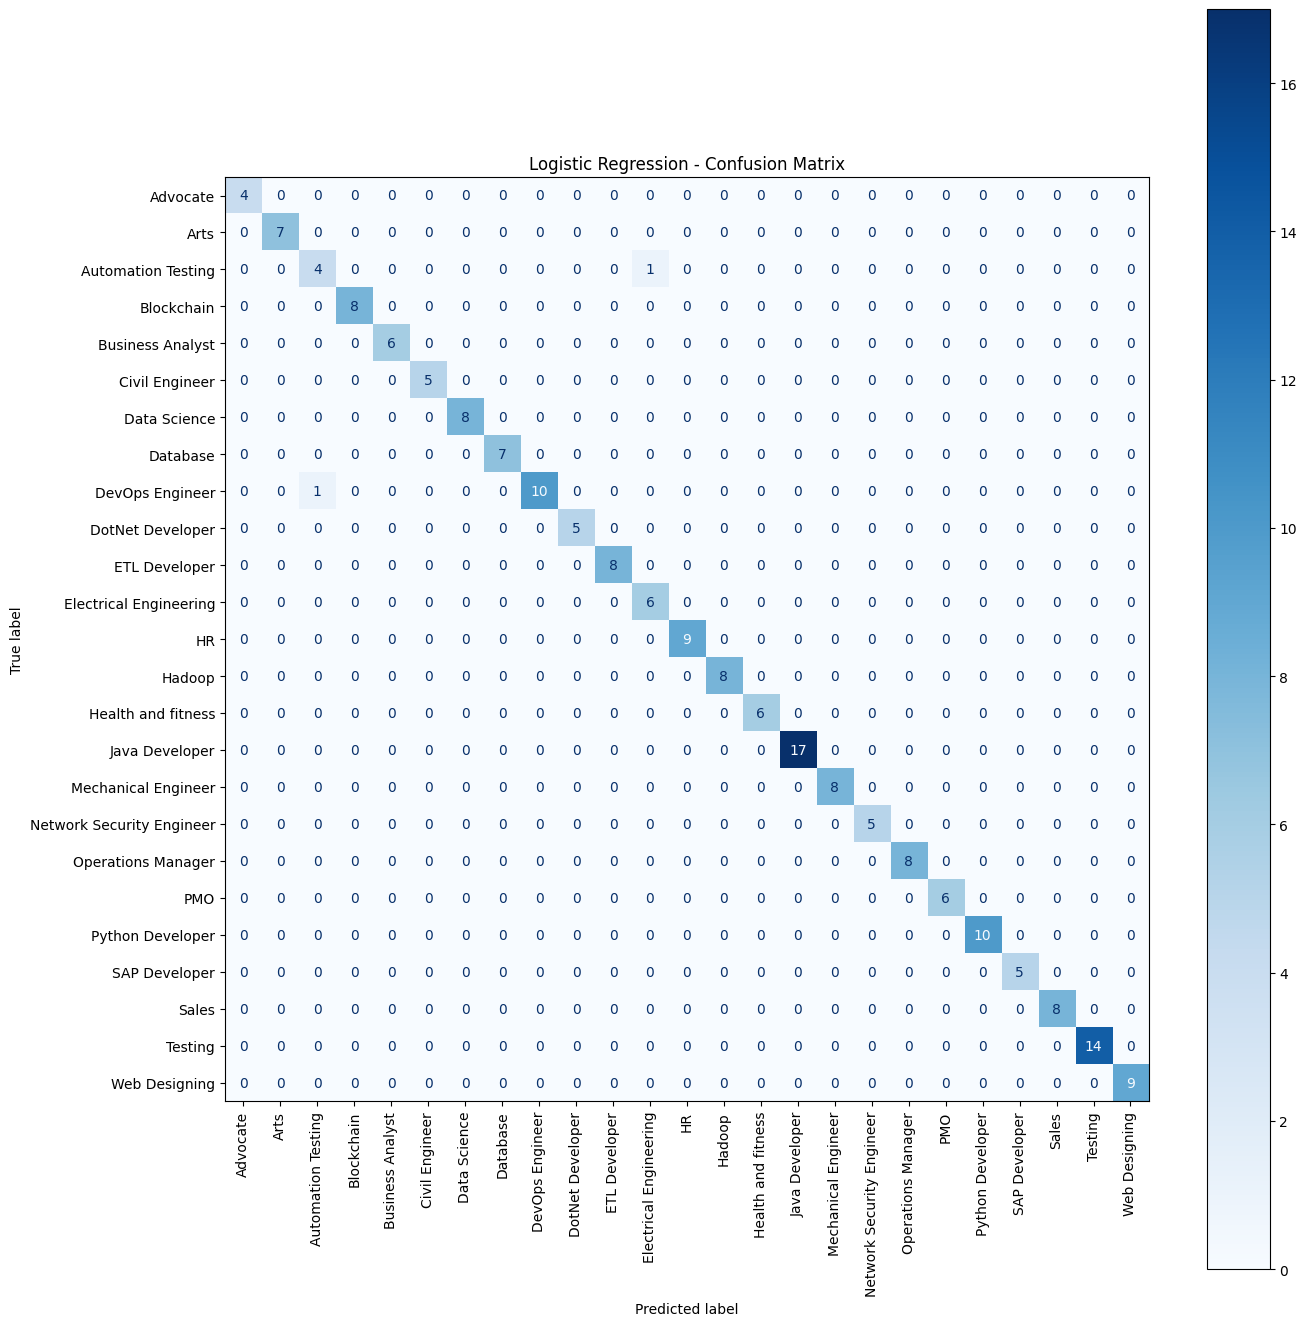

In [21]:
# Colab cell 6
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_, xticks_rotation=90, ax=ax, cmap='Blues'
)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

In [22]:
# Colab cell 7
import joblib

joblib.dump(lr, 'logistic_regression_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

from google.colab import files
files.download('logistic_regression_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

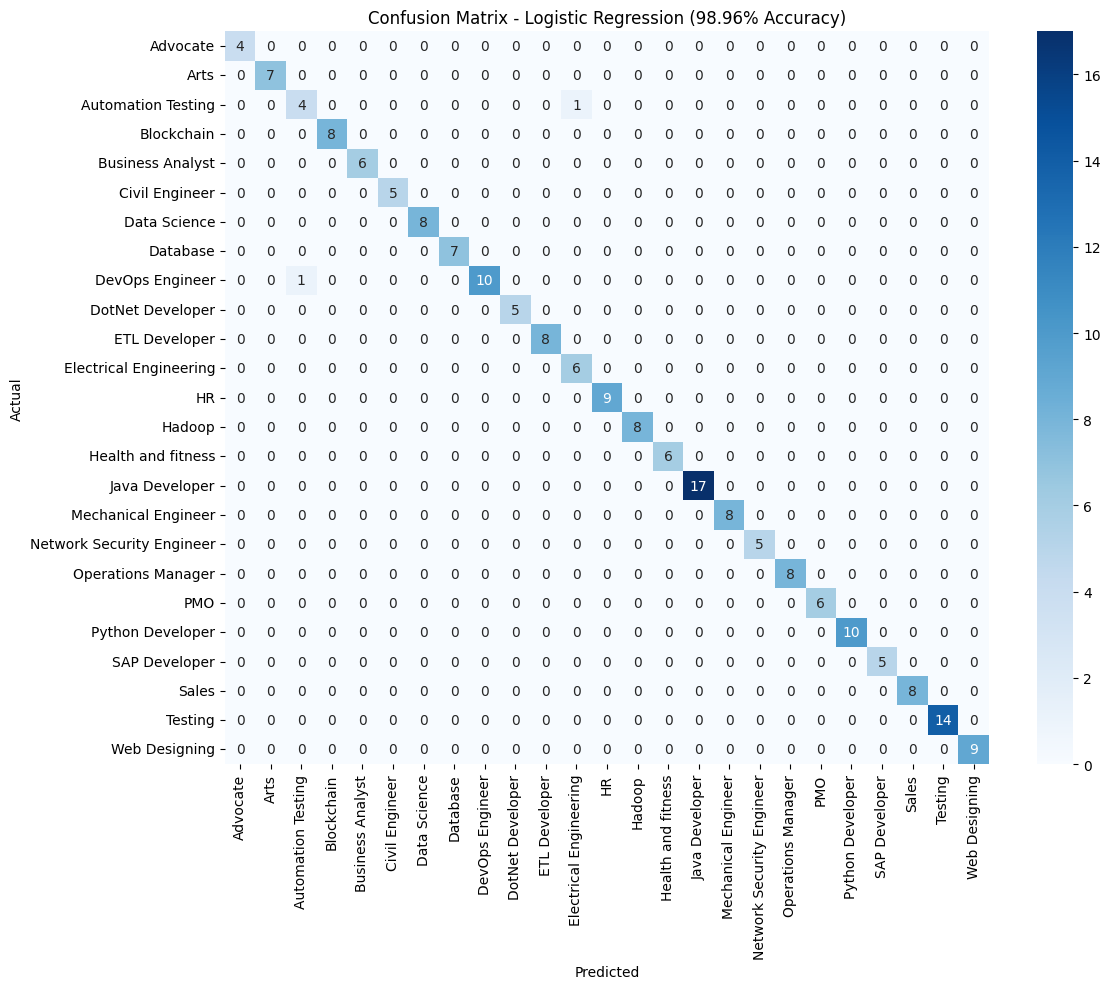

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.80      0.80      0.80         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.86      1.00      0.92         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00      1.00      1.00     

In [23]:
# Colab cell 8
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (98.96% Accuracy)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=300)
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

In [24]:
import pandas as pd
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 1. Load dataset
url = "https://raw.githubusercontent.com/Priyanshu-1729/Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)

# 2. Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'@\S+', '  ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower().strip()
    return text

def preprocess(text):
    text = clean_resume(text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume'].apply(preprocess)

# 3. Label encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])
y = df['Category_encoded']

# 4. Tokenizer + Padding (for LSTM)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 5000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_resume'])
sequences = tokenizer.texts_to_sequences(df['cleaned_resume'])
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# 5. Train/test split
from sklearn.model_selection import train_test_split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y
)

print("Setup complete!")
print("Train shape:", X_train_dl.shape)
print("Test shape:", X_test_dl.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Setup complete!
Train shape: (769, 200)
Test shape: (193, 200)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat = to_categorical(y_test_dl, num_classes=num_classes)

model_lstm2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_lstm2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history_lstm2 = model_lstm2.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_test_dl, y_test_cat),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 273ms/step - accuracy: 0.1053 - loss: 3.1689 - val_accuracy: 0.1969 - val_loss: 3.0177 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - accuracy: 0.2094 - loss: 2.7959 - val_accuracy: 0.3109 - val_loss: 2.3171 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.3563 - loss: 2.1028 - val_accuracy: 0.5699 - val_loss: 1.5713 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.5241 - loss: 1.5415 - val_accuracy: 0.6788 - val_loss: 1.0941 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.6411 - loss: 1.1913 - val_accuracy: 0.8135 - val_loss: 0.7898 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.7165 - loss: 0.9331 - val_accuracy: 0.8446 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.7945 - loss: 0.7287 - val_

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

y_pred_probs_lstm = model_lstm.predict(X_test_dl)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

acc = accuracy_score(y_test_dl, y_pred_lstm)
prec = precision_score(y_test_dl, y_pred_lstm, average='macro', zero_division=0)
rec = recall_score(y_test_dl, y_pred_lstm, average='macro', zero_division=0)
f1 = f1_score(y_test_dl, y_pred_lstm, average='macro', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-Score (macro): {f1:.4f}")
print("\n" + classification_report(y_test_dl, y_pred_lstm, target_names=le.classes_, zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Accuracy: 0.7202
Precision (macro): 0.8392
Recall (macro): 0.7081
F1-Score (macro): 0.7200

                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         4
                     Arts       1.00      0.29      0.44         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      0.50      0.67         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       0.35      1.00      0.52         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       0.91      0.91      0.91        11
         DotNet Developer       0.50      0.20      0.29         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      0.67      0.80         